In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from sklearn.metrics import (
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
books = pd.read_csv('Books.csv',encoding='latin-1')

ratings = pd.read_csv('Ratings.csv', encoding='latin-1')

users = pd.read_csv('Users.csv',encoding='latin-1')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)
print("Users shape:", users.shape)

Books shape: (271360, 8)
Ratings shape: (1149780, 3)
Users shape: (278858, 3)


In [5]:
print("Books:")
display(books.head())

print("\nRatings:")
display(ratings.head())

print("\nUsers:")
display(users.head())

Books:


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...



Ratings:


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6



Users:


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
print("Books columns:")
print(books.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nUsers columns:")
print(users.columns.tolist())

Books columns:
['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']

Ratings columns:
['User-ID', 'ISBN', 'Book-Rating']

Users columns:
['User-ID', 'Location', 'Age']


In [7]:
print("Missing values in Books:")
display(books.isnull().sum())

print("\nMissing values in Ratings:")
display(ratings.isnull().sum())

print("\nMissing values in Users:")
display(users.isnull().sum())

Missing values in Books:


ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64


Missing values in Ratings:


User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


Missing values in Users:


User-ID          0
Location         0
Age         110762
dtype: int64

In [8]:
print(
    ratings['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


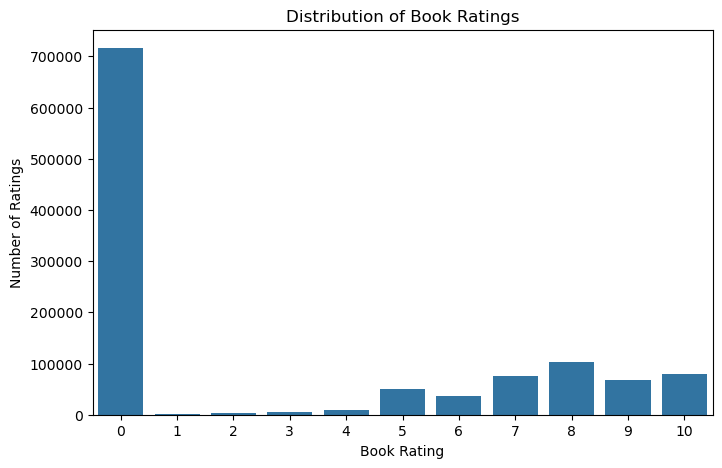

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='Book-Rating',
    data=ratings
)

plt.title('Distribution of Book Ratings')
plt.xlabel('Book Rating')
plt.ylabel('Number of Ratings')

plt.show()

In [11]:
ratings_explicit = ratings[
    ratings['Book-Rating'] > 0
].copy()

print("Original ratings:", ratings.shape)
print("Explicit ratings:", ratings_explicit.shape)

Original ratings: (1149780, 3)
Explicit ratings: (433671, 3)


In [12]:
print(
    ratings_explicit['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


In [14]:
!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------- -----------------------

In [15]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

print("Surprise imported successfully!")

Surprise imported successfully!


In [16]:
cf_data = ratings_explicit[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()

print(cf_data.shape)
display(cf_data.head())

(433671, 3)


,User-ID,ISBN,Book-Rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6


In [17]:
user_counts = cf_data[
    'User-ID'
].value_counts()

active_users = user_counts[
    user_counts >= 10
].index

cf_data = cf_data[
    cf_data['User-ID'].isin(active_users)
].copy()

print("After user filtering:")
print(cf_data.shape)

print(
    "Number of users:",
    cf_data['User-ID'].nunique()
)

After user filtering:
(295561, 3)
Number of users: 7334


In [18]:
book_counts = cf_data[
    'ISBN'
].value_counts()

active_books = book_counts[
    book_counts >= 10
].index

cf_data = cf_data[
    cf_data['ISBN'].isin(active_books)
].copy()

print("After book filtering:")
print(cf_data.shape)

print(
    "Number of users:",
    cf_data['User-ID'].nunique()
)

print(
    "Number of books:",
    cf_data['ISBN'].nunique()
)

After book filtering:
(74907, 3)
Number of users: 6570
Number of books: 3411


In [19]:
display(cf_data.head(10))

,User-ID,ISBN,Book-Rating
133,276822,0060096195,10
141,276822,0552546933,9
145,276822,0786817070,10
182,276847,3426029553,8
210,276847,3551551677,10
211,276847,3551551685,10
289,276861,3423201509,10
413,276925,002542730X,10
429,276925,0385504209,8
587,276929,2266104535,2


In [20]:
reader = Reader(
    rating_scale=(1, 10)
)

In [21]:
data = Dataset.load_from_df(
    cf_data[
        [
            'User-ID',
            'ISBN',
            'Book-Rating'
        ]
    ],
    reader
)

In [22]:
trainset, testset = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

print("Training set created.")
print("Test set size:", len(testset))

Training set created.
Test set size: 14982


In [23]:
svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

In [24]:
print("Training SVD model...")

svd_model.fit(trainset)

print("Training completed!")

Training SVD model...
Training completed!


In [25]:
predictions = svd_model.test(
    testset
)

print("Predictions generated:", len(predictions))

Predictions generated: 14982


In [26]:
rmse = accuracy.rmse(
    predictions,
    verbose=True
)

print("RMSE:", rmse)

RMSE: 1.5462
RMSE: 1.5461914751383692


In [27]:
actual_ratings = [
    prediction.r_ui
    for prediction in predictions
]

predicted_ratings = [
    prediction.est
    for prediction in predictions
]

mse = mean_squared_error(
    actual_ratings,
    predicted_ratings
)

rmse_check = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse_check)

MSE : 2.390708077790566
RMSE: 1.5461914751383692


In [28]:
test_user = cf_data[
    'User-ID'
].iloc[0]

print("Test User ID:", test_user)

Test User ID: 276822


In [29]:
rated_books = set(
    cf_data[
        cf_data['User-ID'] == test_user
    ]['ISBN']
)

print(
    "Books already rated:",
    len(rated_books)
)

Books already rated: 3


In [30]:
all_books = cf_data[
    'ISBN'
].unique()

unrated_books = [
    isbn for isbn in all_books
    if isbn not in rated_books
]

print(
    "Candidate books:",
    len(unrated_books)
)

Candidate books: 3408


In [31]:
candidate_books = unrated_books[:5000]

user_predictions = []

for isbn in candidate_books:
    
    prediction = svd_model.predict(
        test_user,
        isbn
    )
    
    user_predictions.append({
        'ISBN': isbn,
        'Predicted_Rating': prediction.est
    })

predicted_df = pd.DataFrame(
    user_predictions
)

print(
    "Predictions generated:",
    len(predicted_df)
)

Predictions generated: 3408


In [32]:
top_10 = predicted_df.sort_values(
    'Predicted_Rating',
    ascending=False
).head(10)

display(top_10)

,ISBN,Predicted_Rating
2395,0439425220,9.663283
308,059035342X,9.567369
569,0836218787,9.455182
3383,0836213319,9.413006
567,0836204387,9.402844
2237,0743454529,9.390029
1740,0140143505,9.333000
920,0618129022,9.283573
83,0836217691,9.278424
2321,0618002235,9.269058


In [33]:
top_10_books = top_10.merge(
    books[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ],
    on='ISBN',
    how='left'
)

top_10_books = top_10_books[
    [
        'ISBN',
        'Book-Title',
        'Book-Author',
        'Publisher',
        'Predicted_Rating'
    ]
]

display(top_10_books)

,ISBN,Book-Title,Book-Author,Publisher,Predicted_Rating
0,0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,Scholastic,9.663283
1,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,Arthur A. Levine Books,9.567369
2,0836218787,Scientific Progress Goes 'Boink': A Calvin an...,Bill Watterson,Andrews McMeel Publishing,9.455182
3,0836213319,Dilbert: A Book of Postcards,Scott Adams,Andrews McMeel Pub,9.413006
4,0836204387,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,Andrews McMeel Publishing,9.402844
5,0743454529,"My Sister's Keeper : A Novel (Picoult, Jodi)",Jodi Picoult,Atria,9.390029
6,0140143505,84 Charing Cross Road,Helene Hanff,Penguin Books,9.333000
7,0618129022,The Lord of the Rings (Movie Art Cover),J.R.R. Tolkien,Houghton Mifflin Company,9.283573
8,0836217691,Homicidal Psycho Jungle Cat: A Calvin and Hobb...,Bill Watterson,Andrews McMeel Publishing,9.278424
9,0618002235,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,Houghton Mifflin Company,9.269058


In [34]:
RELEVANT_THRESHOLD = 7

actual_binary = np.array([
    1 if rating >= RELEVANT_THRESHOLD else 0
    for rating in actual_ratings
])

predicted_binary = np.array([
    1 if rating >= RELEVANT_THRESHOLD else 0
    for rating in predicted_ratings
])

In [35]:
precision = precision_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

print("Precision:", precision)

Precision: 0.8511571623052488


In [36]:
recall = recall_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

print("Recall:", recall)

Recall: 0.9328580901856764


In [37]:
f1 = f1_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

print("F1 Score:", f1)

F1 Score: 0.8901368346120383


In [38]:
print("=" * 40)
print("Collaborative Filtering Evaluation")
print("=" * 40)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")

Collaborative Filtering Evaluation
Precision : 0.8512
Recall    : 0.9329
F1 Score  : 0.8901
MSE       : 2.3907
RMSE      : 1.5462


In [39]:
def precision_recall_at_k(
    model,
    testset,
    k=10,
    threshold=7
):
    
    user_actual = {}
    user_predicted = {}
    
    # Generate predictions
    predictions = model.test(testset)
    
    for prediction in predictions:
        
        uid = prediction.uid
        
        if uid not in user_actual:
            user_actual[uid] = []
            user_predicted[uid] = []
        
        # Actual relevant item
        if prediction.r_ui >= threshold:
            user_actual[uid].append(
                prediction.iid
            )
        
        # Predicted relevant item
        if prediction.est >= threshold:
            user_predicted[uid].append(
                (prediction.iid, prediction.est)
            )
    
    precision_scores = []
    recall_scores = []
    
    for uid in user_actual:
        
        actual_items = set(
            user_actual[uid]
        )
        
        predicted_items = sorted(
            user_predicted.get(uid, []),
            key=lambda x: x[1],
            reverse=True
        )[:k]
        
        predicted_items = set(
            item[0]
            for item in predicted_items
        )
        
        if len(predicted_items) == 0:
            continue
        
        relevant = (
            actual_items &
            predicted_items
        )
        
        precision_k = (
            len(relevant) /
            len(predicted_items)
        )
        
        recall_k = (
            len(relevant) /
            len(actual_items)
            if len(actual_items) > 0
            else 0
        )
        
        precision_scores.append(
            precision_k
        )
        
        recall_scores.append(
            recall_k
        )
    
    return (
        np.mean(precision_scores),
        np.mean(recall_scores)
    )

In [40]:
precision_at_10, recall_at_10 = (
    precision_recall_at_k(
        svd_model,
        testset,
        k=10,
        threshold=7
    )
)

print(
    f"Precision@10: {precision_at_10:.4f}"
)

print(
    f"Recall@10: {recall_at_10:.4f}"
)

Precision@10: 0.8214
Recall@10: 0.8610


In [41]:
if (
    precision_at_10 + recall_at_10
) > 0:
    
    f1_at_10 = (
        2 *
        precision_at_10 *
        recall_at_10 /
        (
            precision_at_10 +
            recall_at_10
        )
    )
    
else:
    f1_at_10 = 0

print(
    f"F1@10: {f1_at_10:.4f}"
)

F1@10: 0.8407


In [42]:
evaluation_results = pd.DataFrame({
    'Metric': [
        'Precision',
        'Recall',
        'F1 Score',
        'Precision@10',
        'Recall@10',
        'F1@10',
        'MSE',
        'RMSE'
    ],
    
    'Score': [
        precision,
        recall,
        f1,
        precision_at_10,
        recall_at_10,
        f1_at_10,
        mse,
        rmse
    ]
})

display(evaluation_results)

,Metric,Score
0,Precision,0.851157
1,Recall,0.932858
2,F1 Score,0.890137
3,Precision@10,0.821398
4,Recall@10,0.860963
5,F1@10,0.840715
6,MSE,2.390708
7,RMSE,1.546191


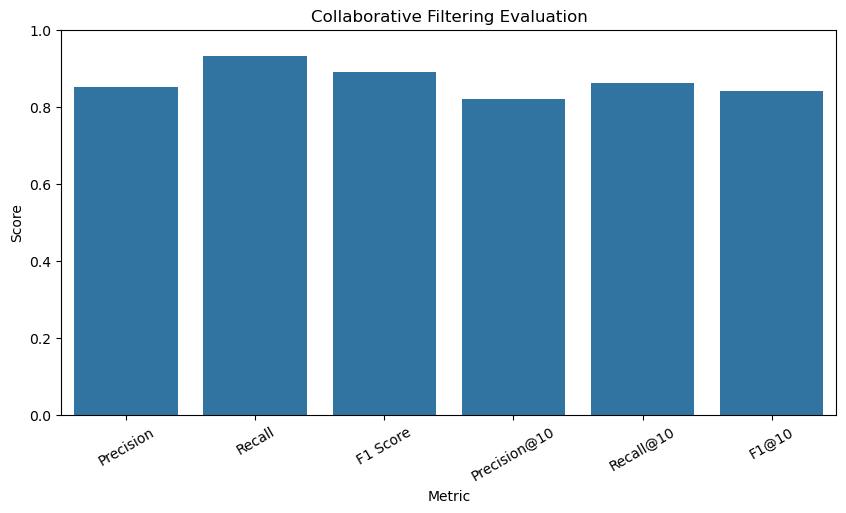

In [43]:
plt.figure(figsize=(10, 5))

metrics_to_plot = evaluation_results[
    evaluation_results['Metric'].isin([
        'Precision',
        'Recall',
        'F1 Score',
        'Precision@10',
        'Recall@10',
        'F1@10'
    ])
]

sns.barplot(
    x='Metric',
    y='Score',
    data=metrics_to_plot
)

plt.title(
    'Collaborative Filtering Evaluation'
)

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.show()

In [45]:
print(
    f"Top 10 Book Recommendations "
    f"for User {test_user}"
)

display(top_10_books)

Top 10 Book Recommendations for User 276822


,ISBN,Book-Title,Book-Author,Publisher,Predicted_Rating
0,0439425220,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,Scholastic,9.663283
1,059035342X,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,Arthur A. Levine Books,9.567369
2,0836218787,Scientific Progress Goes 'Boink': A Calvin an...,Bill Watterson,Andrews McMeel Publishing,9.455182
3,0836213319,Dilbert: A Book of Postcards,Scott Adams,Andrews McMeel Pub,9.413006
4,0836204387,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,Andrews McMeel Publishing,9.402844
5,0743454529,"My Sister's Keeper : A Novel (Picoult, Jodi)",Jodi Picoult,Atria,9.390029
6,0140143505,84 Charing Cross Road,Helene Hanff,Penguin Books,9.333000
7,0618129022,The Lord of the Rings (Movie Art Cover),J.R.R. Tolkien,Houghton Mifflin Company,9.283573
8,0836217691,Homicidal Psycho Jungle Cat: A Calvin and Hobb...,Bill Watterson,Andrews McMeel Publishing,9.278424
9,0618002235,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,Houghton Mifflin Company,9.269058


In [46]:
top_10_books.to_csv(
    'collaborative_filtering_recommendations.csv',
    index=False
)

evaluation_results.to_csv(
    'evaluation_results.csv',
    index=False
)

print("Results saved successfully!")

Results saved successfully!
